git repository with data file - https://github.com/eleonorablazhko/Sexist-Nonsexist-Data.git

**Research**

# **"Linguistic Markers of Sexist Speech: A Data-Driven Analysis"**

Focus on identifying specific language patterns that correlate with sexist content

Analyse word frequencies, sentence structures, and contextual patterns


# Introduction

'Language, as the medium through which we conduct almost all relationships, public and private, bears the precise imprint of our cultural attitudes. The history of language, then, is like a fossil record of how those attitudes have evolved, or how stubbornly they have stayed the same.' David Shariatmadari


In this project, I tried to understand how sexist language appears on the internet today. As a woman, I find this topic both personal and crucial. I used a dataset from Kaggle that contained examples of both sexist and non-sexist text. Using sentiment analysis and machine learning, I discovered something interesting: sexist language isn't always obviously negative. In fact, it often hides behind seemingly positive words while carrying harmful messages. This matches what researchers like Professor Cameron have found about how sexist language has become more sophisticated online. By analyzing features like sentiment scores, punctuation use, and writing style, I found clear differences between sexist and non-sexist texts.
Looking ahead, I hope this research can help social media platforms better identify and prevent online harassment. While this project is just a starting point, understanding these patterns is crucial for making the internet a safer space for women.



# Data Cleaning: Removing noise and irrelevant data.
- Converts to lowercase
- Removes URLs
- Removes special characters and numbers
- Removes extra spaces

Basic dataset handling:

- Loads the CSV
- Removes duplicates
- Shows basic statistics

In [1]:
import numpy as np
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('dev.csv')

def clean(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = ' '.join(text.split())

        return text
    return ""

df.columns = ['id', 'text', 'label', 'sexist', 'category', 'split']

df['text'] = df['text'].apply(clean)
df = df.drop_duplicates()

df.to_csv('cleaned_dev.csv', index=False)

print(f"Cleaned {len(df)} rows and saved to cleaned_dev.csv")

Cleaned 2000 rows and saved to cleaned_dev.csv


Here I am printing some statistics to show labels of sexist content, categories,  etc.

In [3]:
# Statistics
print("\nDataset Statistics:")
print(f"Total rows: {len(df)}")
print("\nDistribution of sexist labels:")
print(df['sexist'].value_counts())
print("\nDistribution of categories:")
print(df['category'].value_counts())


Dataset Statistics:
Total rows: 2000

Distribution of sexist labels:
sexist
none                                        1514
2. derogation                                227
3. animosity                                 167
4. prejudiced discussions                     48
1. threats, plans to harm and incitement      44
Name: count, dtype: int64

Distribution of categories:
category
none                                                               1514
2.1 descriptive attacks                                             102
2.2 aggressive and emotive attacks                                   96
3.1 casual use of gendered slurs, profanities, and insults           91
3.2 immutable gender differences and gender stereotypes              60
4.2 supporting systemic discrimination against women as a group      37
1.2 incitement and encouragement of harm                             36
2.3 dehumanising attacks & overt sexual objectification              29
4.1 supporting mistreatment of individ

# Data Selection

- Balance dataset between sexist/non-sexist content
- Ensure representative samples of each category


I started with a simple graphic of sexist and non-sexist content. As we can see non-sexist content is bigger here, thankfully.

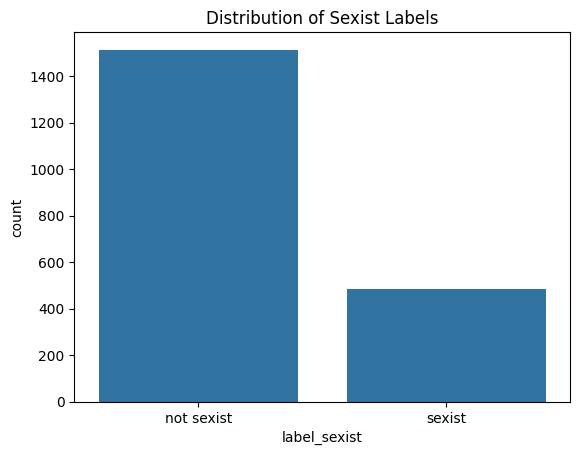

In [4]:
df = pd.read_csv('dev.csv')
sns.countplot(data=df, x='label_sexist')
plt.title('Distribution of Sexist Labels')
plt.show()

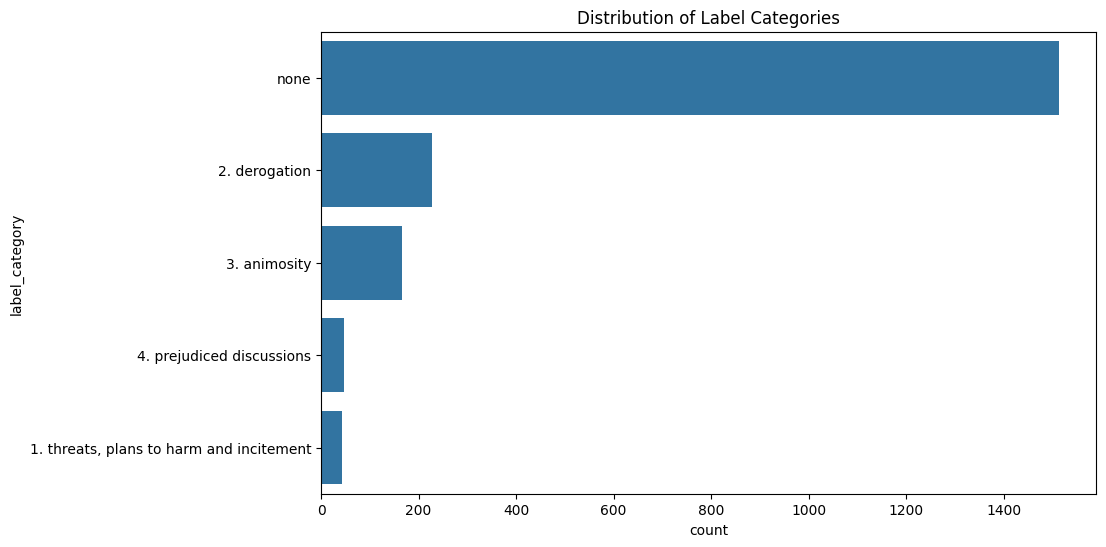

In [5]:
df = pd.read_csv('dev.csv')
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='label_category', order=df['label_category'].value_counts().index)
plt.title('Distribution of Label Categories')
plt.show()

This code converts categorical labels (sexist/not_sexist) into numerical values. This code is perfect for machine learning models.




In [8]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def select_relevant_data(df, text_column='text', label_column='label_sexist'):

    # Convert labels to numeric using LabelEncoder
    le = LabelEncoder()
    y = le.fit_transform(df[label_column])

    # Create TF-IDF features from text
    tfidf = TfidfVectorizer(
        max_features=5000,
        stop_words='english',
        ngram_range=(1, 2)
    )
    X = tfidf.fit_transform(df[text_column])

    # Select top features using chi-square test
    selector = SelectKBest(chi2, k=1000)
    X_selected = selector.fit_transform(X, y)

    # Get selected feature names
    selected_features = np.array(tfidf.get_feature_names_out())[selector.get_support()]

    # Create additional linguistic features
    linguistic_features = pd.DataFrame({
        'text_length': df[text_column].str.len(),
        'word_count': df[text_column].str.split().str.len(),
        'has_exclamation': df[text_column].str.contains('!').astype(int),
        'has_question': df[text_column].str.contains('\?').astype(int),
        'uppercase_ratio': df[text_column].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)))
    })

    return {
        'X_selected': X_selected,
        'y': y,
        'selected_features': selected_features,
        'linguistic_features': linguistic_features,
        'vectorizer': tfidf,
        'label_encoder': le
    }

# **Data Transformation**: Transforming the data into a suitable format or structure

Converts text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency)
Limits to top 5000 most frequent words
Removes English stop words (common words like "the", "is", "at")
Creates a sparse matrix where each row represents a text and each column represents a word's TF-IDF score

In [9]:
df = pd.read_csv('dev.csv')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['text'])
y = df['label_sexist']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

This code analyses data to find signs of gender bias. It looks at things like:

- How many female and male words are used
- If messages use exclamation marks or questions
- How long the messages are
- The ratio of female to male terms

I did this to help find patterns in sexist comments. The code creates a report showing how many messages might be sexist and what features these messages typically have.

In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import re

def transform_data_structure(df):
    df_transformed = df.copy()

    # Gender word lists
    female_terms = {
        'woman', 'women', 'girl', 'girls', 'lady', 'ladies', 'female', 'females',
        'she', 'her', 'hers', 'herself', 'mother', 'daughter', 'sister', 'wife',
        'girlfriend', 'mom', 'mommy', 'mama', 'mrs', 'ms', 'miss'
    }

    male_terms = {
        'man', 'men', 'boy', 'boys', 'gentleman', 'gentlemen', 'male', 'males',
        'he', 'him', 'his', 'himself', 'father', 'son', 'brother', 'husband',
        'boyfriend', 'dad', 'daddy', 'papa', 'mr', 'sir'
    }

    def count_gender_terms(text):
        text = text.lower()
        words = text.split()
        female_count = sum(word in female_terms for word in words)
        male_count = sum(word in male_terms for word in words)
        return female_count, male_count

    le = LabelEncoder()
    df_transformed['label_encoded'] = le.fit_transform(df_transformed['label_sexist'])

    df_transformed['has_exclamation'] = df_transformed['text'].str.contains('!', regex=False).astype(int)
    df_transformed['has_question'] = df_transformed['text'].str.contains(r'\?', regex=True).astype(int)
    df_transformed['is_long_text'] = (df_transformed['text'].str.len() > 100).astype(int)
    df_transformed['word_count'] = df_transformed['text'].str.split().str.len()
    df_transformed['avg_word_length'] = df_transformed['text'].apply(
        lambda x: sum(len(word) for word in str(x).split()) / len(str(x).split()) if len(str(x).split()) > 0 else 0
    )

    df_transformed['female_terms_count'], df_transformed['male_terms_count'] = zip(
        *df_transformed['text'].apply(count_gender_terms)
    )
    df_transformed['gender_term_ratio'] = df_transformed.apply(
        lambda row: row['female_terms_count'] / row['male_terms_count']
        if row['male_terms_count'] > 0 else row['female_terms_count'] if row['female_terms_count'] > 0 else 0,
        axis=1
    )
    final_df = pd.DataFrame({
        'text': df_transformed['text'],
        'label': df_transformed['label_encoded'],
        'exclamation_flag': df_transformed['has_exclamation'],
        'question_flag': df_transformed['has_question'],
        'long_text_flag': df_transformed['is_long_text'],
        'word_count': df_transformed['word_count'],
        'avg_word_length': df_transformed['avg_word_length'],
        'female_terms': df_transformed['female_terms_count'],
        'male_terms': df_transformed['male_terms_count'],
        'gender_term_ratio': df_transformed['gender_term_ratio']
    })

    print("Transformation Summary:")
    print(f"Total samples: {len(final_df)}")

    print("\nLabel distribution:")
    print(pd.value_counts(final_df['label']))

    print("\nFeature flags summary:")
    print(final_df[['exclamation_flag', 'question_flag', 'long_text_flag']].sum())

    print("\nGender terms statistics:")
    gender_stats = final_df[['female_terms', 'male_terms', 'gender_term_ratio']].describe()
    print(gender_stats)

    print("\nText statistics:")
    print(final_df[['word_count', 'avg_word_length']].describe())

    return final_df


df = pd.read_csv('dev.csv')
transformed_df = transform_data_structure(df)

Transformation Summary:
Total samples: 2000

Label distribution:
label
0    1514
1     486
Name: count, dtype: int64

Feature flags summary:
exclamation_flag     199
question_flag        335
long_text_flag      1175
dtype: int64

Gender terms statistics:
       female_terms   male_terms  gender_term_ratio
count   2000.000000  2000.000000        2000.000000
mean       0.929000     0.271000           0.897592
std        0.977464     0.672149           0.963732
min        0.000000     0.000000           0.000000
25%        0.000000     0.000000           0.000000
50%        1.000000     0.000000           1.000000
75%        1.000000     0.000000           1.000000
max        8.000000     6.000000           8.000000

Text statistics:
        word_count  avg_word_length
count  2000.000000      2000.000000
mean     23.033500         4.568218
std      11.794063         0.901014
min       1.000000         2.555556
25%      13.000000         4.088235
50%      21.500000         4.444444
75%    

<ipython-input-10-b4fc140eb2e2>:64: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(final_df['label']))


## Data Mining: Employing techniques to extract patterns.

Here I did Clustering, to be exact Hierarchical clustering Agglomerative (“Bottom-up”). I chose this type of clustering because: Firstly it's good at finding natural groupings in text data; it works well with the PCA (Principal Component Analysis) I used it to simplify my text data into 2 dimensions.

Basically this code groups similar text messages together to understand the difference between sexist and non-sexist content. Here's what it does:

- Takes a random sample of 100 messages from data
- Converts the text into numbers that a computer can analyse
- Creates a visual map (scatter plot) that shows two groups:
 - Red dots for likely sexist content
 - Blue dots for likely non-sexist content

This code shows:

1. How many messages are in each group
2. Examples of messages from each group
3. The most common words used in each group

I did clustering to see if sexist and non-sexist messages naturally form different patterns that computers can spot. This might help automatically identify harmful content online.



Cluster Analysis:

Sexist Content:
Number of texts: 74

Sample texts from this cluster:
- as visions of dancing boys dance in their heads with delusions of rape anytime anywhere their daughters bedroom is no longer off limits

- dont fucking worry about it in my experience girls are more attracted to status and confidence projected status than they are to looks anyway

- rapists can burn to the deepest of hells that said its not my obligation nor duty to prevent that from happening

Most common words: the, to, you, of, that

Non-Sexist Content:
Number of texts: 26

Sample texts from this cluster:
- i stopped giving them advice about it and yea there is alot of hate of seddit but that is life maybe they will learn one day

- i find her actually cute tbh but yeah any sub lbs woman nowadays is a godess among simps

- however there is a slight chance hispanics would rather watch fat men interview hot bikini girls in a jacuzzi

Most common words: her, and, is, she, woman


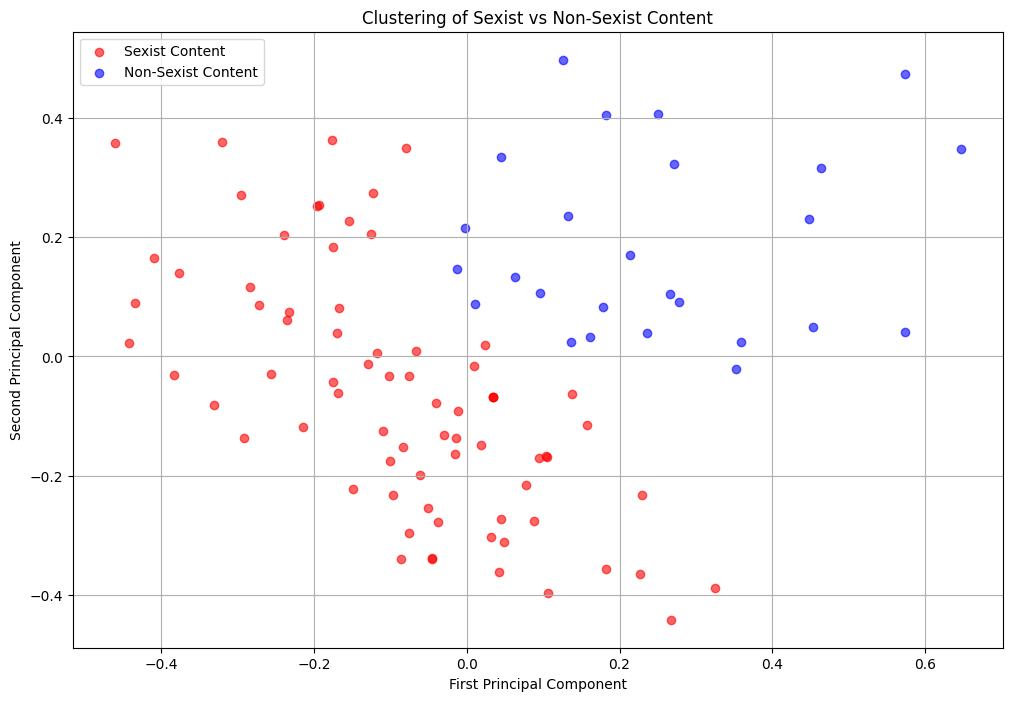

In [11]:
df = pd.read_csv('cleaned_dev.csv')
sample_size = 100
df_sample = df.sample(n=sample_size, random_state=42)

vectorizer = TfidfVectorizer(max_features=50)
X = vectorizer.fit_transform(df_sample['text'])

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X.toarray())

n_clusters = 2
clustering = AgglomerativeClustering(n_clusters=n_clusters)
clusters = clustering.fit_predict(X_2d)

plt.figure(figsize=(12, 8))

colors = ['red', 'blue']
labels = ['Sexist Content', 'Non-Sexist Content']

for i in range(n_clusters):
    mask = clusters == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[i],
                label=labels[i],
                alpha=0.6)

plt.title('Clustering of Sexist vs Non-Sexist Content')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.legend()
plt.grid(True)

print("\nCluster Analysis:")
for i in range(n_clusters):
    cluster_texts = df_sample[clusters == i]
    print(f"\n{labels[i]}:")
    print(f"Number of texts: {len(cluster_texts)}")

    print("\nSample texts from this cluster:")
    for text in cluster_texts['text'].head(3):
        print(f"- {text}\n")

    cluster_features = vectorizer.transform(cluster_texts['text'])
    feature_sum = cluster_features.sum(axis=0).A1
    top_indices = feature_sum.argsort()[-5:][::-1]
    top_words = [vectorizer.get_feature_names_out()[i] for i in top_indices]
    print(f"Most common words: {', '.join(top_words)}")

**Sentiment Analysis** is a Natural Language Processing (NLP) technique that determines the emotional tone or opinion expressed in text data. This technique really suits my research topic. I wanted to explore more the tone and feeling of a text and what makes is sexist.


After receiving recommendations from my lecturer, I decided to implement SA in my research to provide deeper insights into emotional patterns. I used the original dataset rather than the cleaned version to ensure I captured the authentic linguistic patterns.

Here, I analysed the tone and emotional characteristics of sexist vs non-sexist texts. I was particularly interested in understanding how these two types of content differ in their expression and emotional delivery.
So here are some key aspects of this code:

- The overall sentiment (positive/negative tone)
- Use of exclamation marks
- Use of question marks
- Use of uppercase letters (which people often use to show emotions)

What I found was quite fascinating. Initially, I expected sexist content to be more obviously negative, but my analysis showed something more subtle. The sexist texts actually had a slightly higher positive sentiment score (0.018) compared to non-sexist texts (0.007). This was a surprising discovery that made me realise sexist language often masks itself behind seemingly positive expressions. Looking at my example texts, I can clearly see this pattern. One of the non-sexist texts straightforwardly expresses enthusiasm about a YouTube channel, while a sexist text uses superficially positive words ("Beautiful woman") but pairs them with controlling or judgmental messages.
I also noticed interesting patterns in writing style. Non-sexist texts tended to use more expressive punctuation and emphasis:

- More exclamation marks (0.16 vs 0.13)
- More question marks (0.23 vs 0.16)
- More uppercase text (4.6% vs 3.1%)

This tells me that non-sexist texts are more openly expressive in general, while sexist texts tend to be more controlled in their punctuation use, perhaps attempting to appear more "reasonable" or "measured" while delivering problematic content. These findings have really helped me understand how sexist language often operates in subtle ways, hiding behind 'positive' or 'neutral' language rather than being openly negative. This makes the task of identifying and analysing sexist content more complex than simply looking for negative words or angry tones.

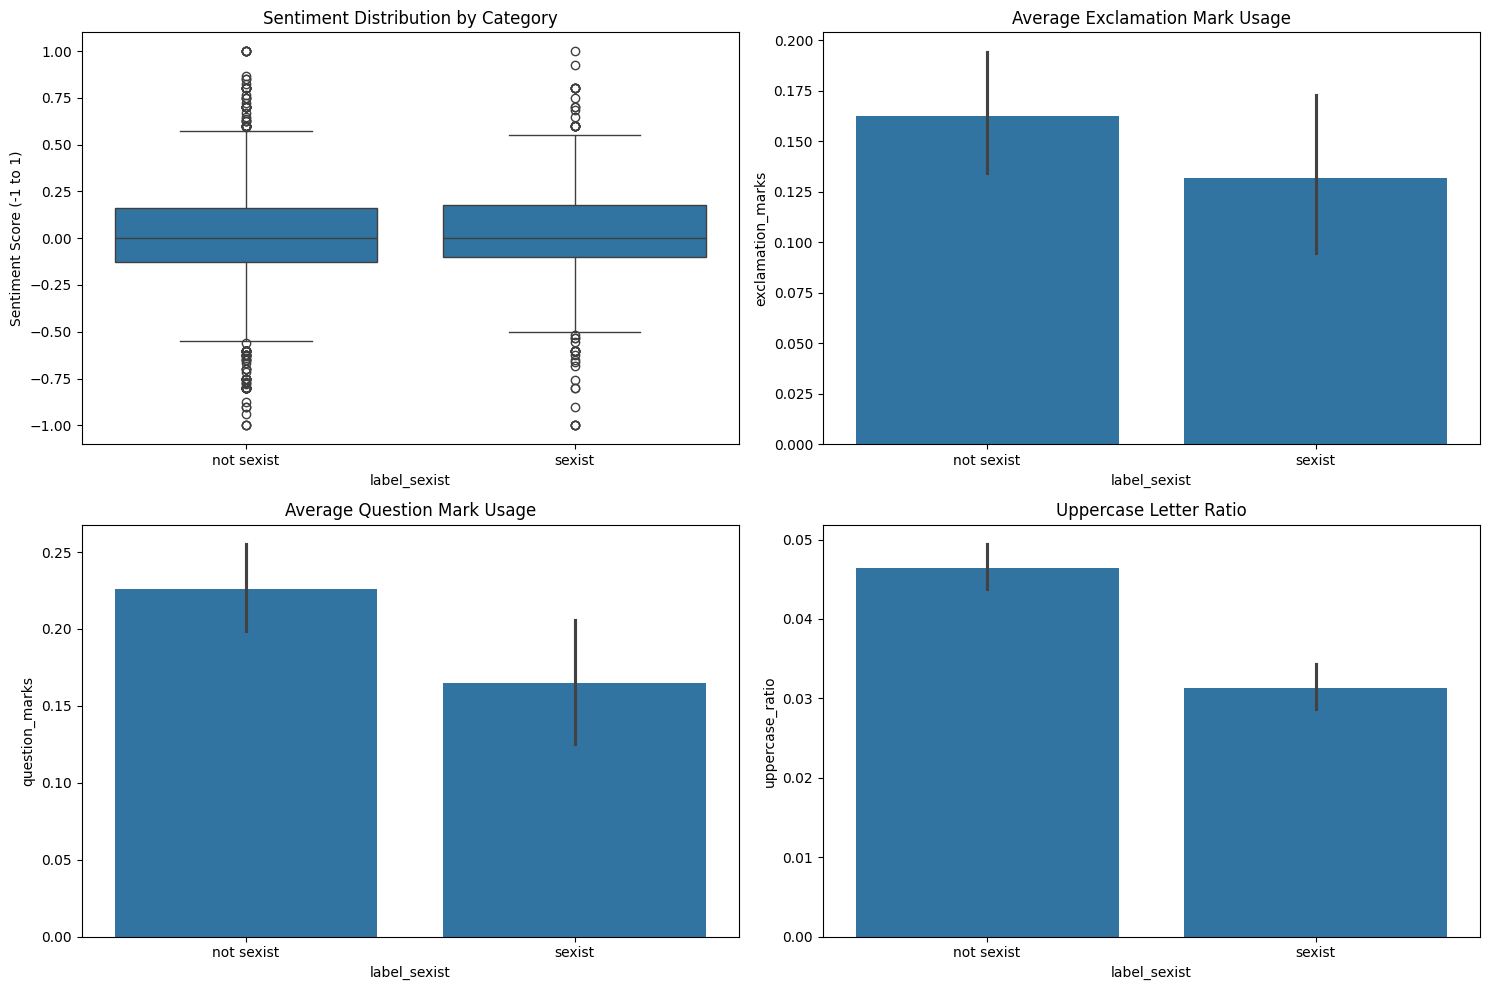


Tone Analysis Summary:
--------------------------------------------------

Category: not sexist
Average sentiment: 0.007
Exclamation marks per text: 0.16
Question marks per text: 0.23
Uppercase ratio: 0.046

Example texts with strong sentiment:
- Awesome, did you guys study the origin of the aryans?
- [USER] dude check her youtube channel, she is fuckin awesome

Category: sexist
Average sentiment: 0.018
Exclamation marks per text: 0.13
Question marks per text: 0.16
Uppercase ratio: 0.031

Example texts with strong sentiment:
- She is the perfect whore of babylon
- Beautiful woman, beautiful child! #BeautifulNotSlutty


In [18]:
df = pd.read_csv('dev.csv')
def analyze_text_tone(df, text_column='text', label_column='label_sexist'):

    analysis_df = df.copy()
    analysis_df['sentiment'] = analysis_df[text_column].apply(
        lambda x: TextBlob(str(x)).sentiment.polarity
    )
    # some calculations for statistics
    analysis_df['exclamation_marks'] = analysis_df[text_column].str.count('!')
    analysis_df['question_marks'] = analysis_df[text_column].str.count('\?')
    analysis_df['uppercase_ratio'] = analysis_df[text_column].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x))
    )

    plt.figure(figsize=(15, 10))

    # 1. Sentiment Distribution
    plt.subplot(2, 2, 1)
    sns.boxplot(x=label_column, y='sentiment', data=analysis_df)
    plt.title('Sentiment Distribution by Category')
    plt.ylabel('Sentiment Score (-1 to 1)')

    # 2. Exclamation Mark Usage
    plt.subplot(2, 2, 2)
    sns.barplot(x=label_column, y='exclamation_marks', data=analysis_df)
    plt.title('Average Exclamation Mark Usage')

    # 3. Question Mark Usage
    plt.subplot(2, 2, 3)
    sns.barplot(x=label_column, y='question_marks', data=analysis_df)
    plt.title('Average Question Mark Usage')

    plt.subplot(2, 2, 4)
    sns.barplot(x=label_column, y='uppercase_ratio', data=analysis_df)
    plt.title('Uppercase Letter Ratio')

    plt.tight_layout()
    plt.show()

    # printing statistics
    print("\nTone Analysis Summary:")
    print("-" * 50)

    for category in df[label_column].unique():
        category_data = analysis_df[analysis_df[label_column] == category]
        print(f"\nCategory: {category}")
        print(f"Average sentiment: {category_data['sentiment'].mean():.3f}")
        print(f"Exclamation marks per text: {category_data['exclamation_marks'].mean():.2f}")
        print(f"Question marks per text: {category_data['question_marks'].mean():.2f}")
        print(f"Uppercase ratio: {category_data['uppercase_ratio'].mean():.3f}")
        print("\nExample texts with strong sentiment:")
        extreme_sentiment = category_data.nlargest(2, 'sentiment')['text']
        for text in extreme_sentiment:
            print(f"- {text}")

    return analysis_df

results = analyze_text_tone(df)


**Logistic Regression model**
This code trains a machine learning model to automatically identify and classify texts as sexist or non-sexist based on their content.
I found this code interesting and decided to implement it in my research.

## Knowledge Presentation

In [19]:
# This code was taken from ARIF MIAH "Classifying Sexist Content in English Text Using N". Link: https://www.kaggle.com/code/arifmia/classifying-sexist-content-in-english-text-using-n
# I modified code a bit, but it wasn't my idea
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f'Validation Accuracy: {accuracy:.2f}')
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.75
              precision    recall  f1-score   support

  not sexist       0.75      1.00      0.86       296
      sexist       0.86      0.06      0.11       104

    accuracy                           0.75       400
   macro avg       0.80      0.53      0.48       400
weighted avg       0.78      0.75      0.66       400



**Sentiment Distribution Pie Chart**

In this code, I used TextBlob to perform the sentiment analysis.
It's something similar to what I did earlier in the project, but using a simpler library. It takes each text and gives it a mood score, for exxample: negative scores (-1) for sad/angry tone; positive scores (+1) for happy/positive tone and zero for neutral tone.

I made a pie chart to show how the texts are divided into section with neutral one. While this gives a quick overview of the emotional tone of the data, it's a basic analysis.

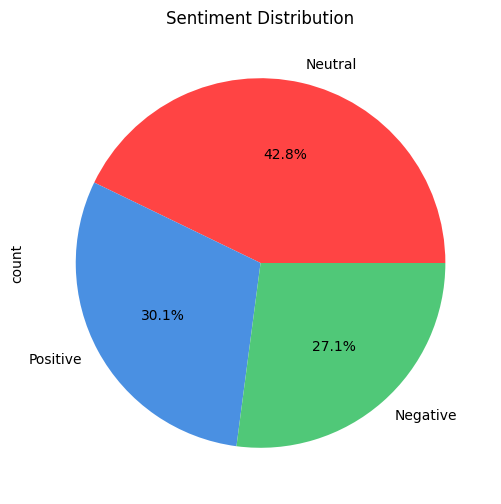

In [20]:
df = pd.read_csv('cleaned_dev.csv')
def analyze_sentiment(df, text_column='text'):
    df['sentiment'] = df[text_column].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

    df['sentiment_category'] = pd.cut(df['sentiment'],
                                    bins=[-1, -0.1, 0.1, 1],
                                    labels=['Negative', 'Neutral', 'Positive'])

    plt.figure(figsize=(8, 6))
    df['sentiment_category'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                               colors=['#FF4444', '#4A90E2', '#50C878'])
    plt.title('Sentiment Distribution')
    plt.show()
    return df


df_with_sentiment = analyze_sentiment(df)

**Content Distribution Pie Chart**

Content Distribution:
sexist
none                                        1514
2. derogation                                227
3. animosity                                 167
4. prejudiced discussions                     48
1. threats, plans to harm and incitement      44
Name: count, dtype: int64


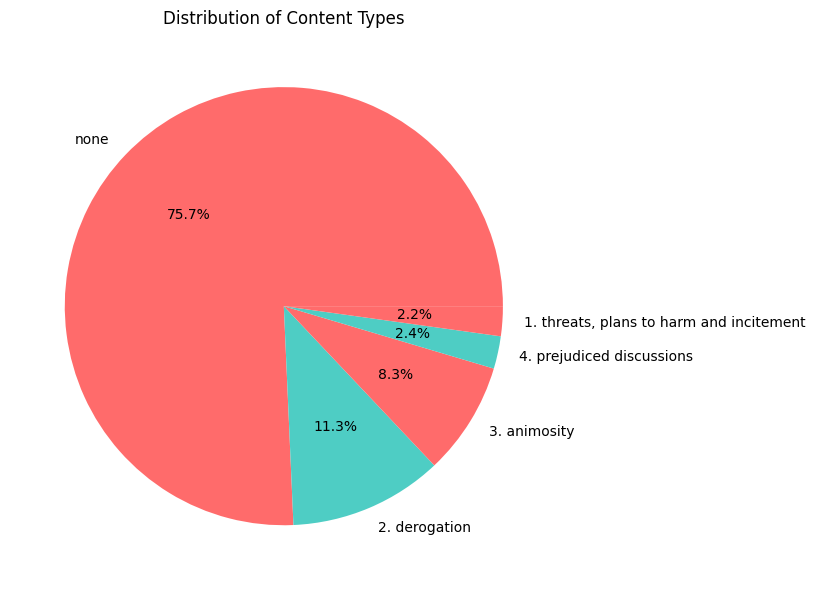

In [23]:
def create_content_distribution_chart(df):
    fig, ax = plt.subplots(figsize=(8, 6))

    content_distribution = df['sexist'].value_counts()
    ax.pie(content_distribution.values, labels=content_distribution.index, autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'])

    ax.set_title('Distribution of Content Types')
    plt.tight_layout()

    print("Content Distribution:")
    print(content_distribution)

df = pd.read_csv('cleaned_dev.csv')
create_content_distribution_chart(df)

# Conclusion

Based on my research analysing the linguistic markers of sexist speech using sentiment analysis and machine learning techniques, I discovered several key patterns in how sexist language manifests online. My analysis revealed that sexist content often hides behind seemingly positive language, with sexist texts showing slightly higher positive sentiment scores than non-sexist texts. This aligns with Professor Cameron's observation about how modern sexism has evolved to be more subtle and insidious, particularly in online spaces.
Through my text analysis, I found that non-sexist content tends to be more expressively written, using more punctuation and emphasis, while sexist content often adopts a more controlled, more "reasonable" tone. Like Cameron's findings about the "policing" of women's language, my research shows that detecting sexist content isn't as simple as looking for obvious negative language or aggressive tone. Instead, it requires understanding subtle linguistic patterns and contextual markers.
This research contributes to the broader understanding of how modern sexist speech operates online and could help in developing better methods to identify and address it.

# References:


Kaggle, where I took data and some inspiration for my project: https://www.kaggle.com/datasets/aadyasingh55/sexism-detection-in-english-texts/code

Book 'Language, Sexism and Misogyny' By Deborah: Cameronhttps://www.routledge.com/Language-Sexism-and-Misogyny/Cameron/p/book/9781032277943?_gl=1*19972nf*_ga*MTE5MDQyMTA0Ni4xNjg4OTk0NjQy*_ga_0HYE8YG0M6*MTY5ODIyOTA2OC40MS4xLjE2OTgyMzAzODYuMC4wLjA.&_ga=2.39157475.1170379004.1733785509-1670649033.1733785509

Article 'Internet is Fuelling New Wave of Misogyny, Says Linguistics Expert': https://newsroom.taylorandfrancisgroup.com/internet-is-fuelling-new-wave-of-misogyny-says-linguistics-expert/

Article by David Shariatmadari 'Eight words that reveal the sexism at the heart of the English language': https://www.theguardian.com/commentisfree/2016/jan/27/eight-words-sexism-heart-english-language